# Especialidad en Métodos Estadísticos a Distancia (EMED)
## Modulo 6: Optimización
## Unidad IV: Optimización Estocástica
## Iván de Luna Aldape

In [1]:
import numpy as np
from sklearn.utils import check_random_state, check_X_y, shuffle
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn import datasets
import matplotlib.pyplot as plt
import pandas as pd


### 1. Considere los siguientes problemas de optimización:
Usando búsqueda aleatoria, encuentre la solución a los problemas de optimización. Utilice 10,000 puntos en la búsqueda.

Primero definimos el algoritmo para la búsqueda aleatoria:

In [2]:
import numpy as np
from sklearn.utils import check_random_state

def random_search(fun, n_dim, lower_bound = 0, upper_bound = 1, max_iters = 1000, random_state = None):
    """Búsqueda aleatoria pura

    Args:
        fun (función): función objetivo a optimizar
        n_dim (int): numero de variables en la función objetivo
        lower_bound (int, array): límite inferior que puede tomar cada variable
        upper_bound (int, array): límite superior que puede tomar cada variable
        max_iters (int): máximo número de iteraciones
        random_state (_type_, optional): manejador de números aletorios
    """
    
    # Inicializar manejador de números aletorios
    random_state = check_random_state(random_state)
    
    # Inicializar valores
    best_val = np.infty
    best_sol = None
    path = []
    
    # Búsqueda aleatoria
    for _ in range(max_iters):
        candidate = random_state.uniform(low = lower_bound, high = upper_bound, size = (n_dim))
        obj_val = fun(candidate)
        if obj_val < best_val:
            best_val = obj_val
            best_sol = candidate
            path.append(best_val)
    return best_val, best_sol, path

a) 

$$
\begin{array}{lc}
\min & 300 + \sum(x_{i}^2 - 10\cos(2 \pi x_{i})) \\
s.t. & -5.12 \leq x_{i} \leq 5.12, \forall  i  \in \{1,..,30\} \\
\end{array}
$$

Se genera la solución óptima:

In [3]:
# Gráfica de la función objetivo
fo1 = lambda x: 300 + sum([x[i]**2 - 10*np.cos(2*np.pi*x[i]) for i in range(len(x))])

val1, sol1, path1 = random_search(fo1, 1, -5.12, 5.12, 10000)

In [4]:
print(val1, sol1)

290.00001799886115 [0.0003012]


El algoritmo tarda 8 pasos en llegar a la solución óptima, empezando en 321.36 y finalizando en 290.000

In [5]:
def highlight_max(s, props=''):
    return np.where(s == np.nanmax(s.values), props, '')

def highlight_min(s, props=''):
    return np.where(s == np.nanmin(s.values), props, '')

df1 = pd.DataFrame(path1)
df1.style.apply(highlight_max, props='color:black;background-color:yellow', axis=0)\
        .apply(highlight_min, props='color:white;background-color:darkblue', axis=0 )


,0
0,309.591718
1,300.364050
2,293.278302
3,291.181980
4,291.000528
5,290.073861
6,290.007209
7,290.000810
8,290.000191
9,290.000018


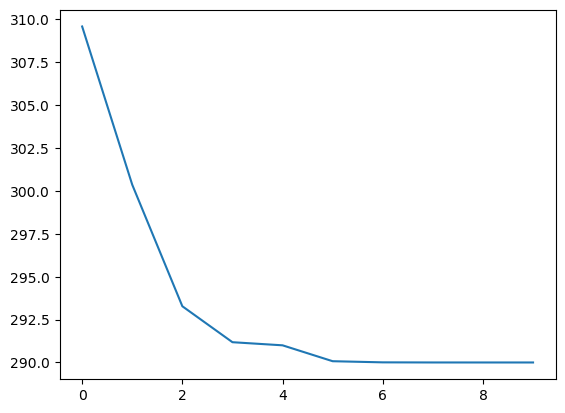

In [6]:
plt.plot(path1)

b)

$$
\begin{array}{lc}
\min & -20 \exp \left(-\frac{2}{10} \sqrt{\frac{1}{10} \sum_{i=1}^{10}x_{i}^2}\right) - \exp\left(\frac{1}{10} \sum_{i=1}^{10}\cos(2 \pi x_{i})\right) + 20 + \exp(1) \\
s.t. & -32.768 \leq x_{i} \leq 32.768, \forall i \in \{1,..,10\} \\
\end{array}
$$

Se corre el algoritmo y se obtiene una solución óptima:

In [7]:
fo2 = lambda x: (-20)*np.exp((-2/10)*np.sqrt((1/10)*sum([x[i]**2 for i in range(len(x))]))) - np.exp((1/10)*sum([np.cos(2*np.pi*(x[i])) for i in range(len(x))])) + 20 + np.exp(1)
val2, sol2, path2 = random_search(fo2, 1, -32.768, 32.768, 10000)

In [8]:
print(val2, sol2)

1.6197874459598265 [0.00523193]


En este caso se tardo 12 pasos en encontrarla, siendo que empezó en 13.93 y terimna en 1.6197.

In [9]:
df2 = pd.DataFrame(path2)
df2.style.apply(highlight_max, props='color:black;background-color:yellow', axis=0)\
        .apply(highlight_min, props='color:white;background-color:darkblue', axis=0 )

,0
0,13.936665
1,13.338078
2,2.414350
3,2.054538
4,2.044931
5,1.925555
6,1.898602
7,1.885518
8,1.809434
9,1.658971


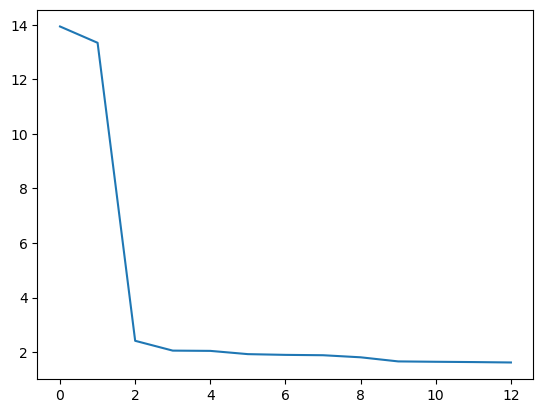

In [10]:
plt.plot(path2)

c)

$$
\begin{array}{lc}
\min & \sum_{i=1}^{10}\left( \sum_{j=1}^{d}(10 + j)(x_j^i - \frac{1}{j^i}) \right)^2 \\
s.t. & -10 \leq x_{i} \leq 10, \forall i \in \{1,..,10\} \\
\end{array}
$$

En este caso se tienen dos indices, $i, j$, lo cual puede abarcar más criterios de búsqueda.

In [11]:
fo3 = lambda x: sum([(sum([(10 + j)*((x[j]**i) - (1/(j**i))) for j in range(1, len(x))]))**2 for i in range(1,10)])
val3, sol3, path3 = random_search(fo3, 2, -10, 10, 10000)

In [12]:
print(val3, sol3)

0.09223701849382973 [-4.53308173  1.00162734]


En un inicio empieza con un número excesivamente grande, pero rápidamente el algoritmo va ubicando el punto óptimo lográndolo en 10 pasos.

In [13]:
df3 = pd.DataFrame(path3)
df3.style.apply(highlight_max, props='color:black;background-color:yellow', axis=0)\
        .apply(highlight_min, props='color:white;background-color:darkblue', axis=0 )

,0
0,69111352725635252224.000000
1,6221924248513571.000000
2,523607326744.967590
3,1588.215869
4,1113.456870
5,508.353193
6,362.597788
7,120.813406
8,2.773710
9,1.112764


En este caso no se aprecian bien los pasos por la magnitud de los primeros valores, dando un efecto de línea recta.

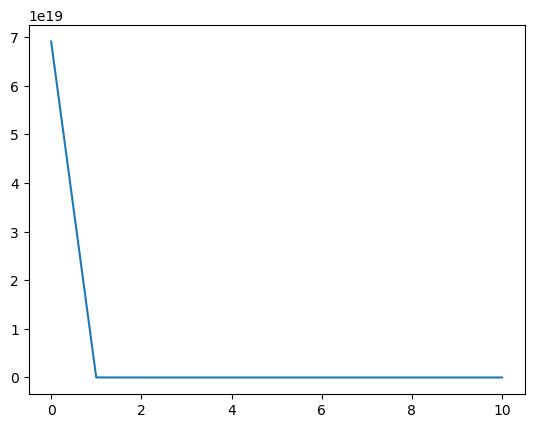

In [14]:
plt.plot(path3)

### 2. Resuelva los problemas de optimización del ejercicio 1, usando evolución diferencial (DE/Rand/1/bin) con un tamaño de población de 100, durante 100 iteraciones y los parámetros $F = 0.5$ y $CR = 0.5$.

Primero se define el algoritmo:

In [15]:
import numpy as np
from sklearn.utils import check_random_state

def differential_evolution(fun, n_dim, lower_bound = 0, upper_bound = 1, population_size = 100, CR = 0.5, F = .05, max_iters = 100, random_state = None):
  """Evolución Diferencial

  Args:
      fun (funcion): Funcion objetivo a optimizar
      n_dim (int): número de variables del problema de optimización
      lower_bound (int, optional): limite inferior de las variables. Defaults to 0.
      upper_bound (int, optional): límite superior de las variables. Defaults to 1.
      population_size (int, optional): número de individuos en la población. Defaults to 100.
      CR (float, optional): tasa de cruza. Defaults to 0.5.
      F (float, optional): peso diferencial. Defaults to .05.
      max_iters (int, optional): número máxio de iteraciones/generaciones. Defaults to 100.
      random_state (int, optional): semilla de los números aleatorios. Defaults to None.
  """
  
  # Inicializar manejador de números aleatorios
  random_state = check_random_state(random_state)
  
  # Crear la población inicial
  population = random_state.uniform(size = (population_size, n_dim))
  
  # Evaluando la aptitud de cada individuo de la población
  fit = [fun(np.subtract(upper_bound, lower_bound) * ind + lower_bound) for ind in population]
  
  for _ in range(max_iters):
    # Selección aleatoria de tres individuos para la mutación direccional
    r1, r2, r3 = np.argsort(random_state.uniform(size = (population_size, population_size))).T[:3]
    # Creando el vector de prueba usando la mutación direccional
    trial = np.clip(population[r1] + F * (population[r2] - population[r3]), 0, 1)
    # Cruza binomial
    # Definiendo los puntos de cruza
    cross_points = random_state.uniform(size = (population_size, n_dim)) < CR
    is_any_true = np.all(~ cross_points, axis = 1)
    if np.any(is_any_true):
      cross_points[is_any_true, np.random.randint(n_dim, size = (is_any_true.sum()))] = True
    offspring = population.copy()
    offspring[cross_points] = trial[cross_points]
    # Evaluando el fitness de la población descendiente
    fit_offspring = [fun(np.subtract(upper_bound, lower_bound) * ind + lower_bound) for ind in offspring]
    # Seleccionando los individuos de la siguiente generación
    is_better = np.where(fit_offspring < fit, True, False)
    if np.any(is_better):
      population[is_better] = offspring[is_better]
      fit = np.where(is_better, fit_offspring, fit)
      
    return np.add(np.subtract(upper_bound, lower_bound) * population, lower_bound), fit

Se crea una función en donde se van a guardar 5 iteraciones de correr el algoritmo definido:

In [41]:
#differential_evolution(fo1, 1, -5.12, 5.12, 100, 0.5, 0.5, 100)

def resultados(n):
    resultado = []
    i = 1
    while i <= n:
        resultado.append(differential_evolution(fo1, 1, -5.12, 5.12, 100, 0.5, 0.5, 100))
        i = i + 1
    return resultado

res4 = resultados(5)

En este caso vemos como evoluciona el fit de los resultados, visualizando los primeros tres, siendo que en promedio el valor rondará:

In [45]:
np.mean(res4[0][1])

309.84160923595186

Se checa con el segundo resultado:

In [46]:
np.mean(res4[1][1])

307.7391561651248

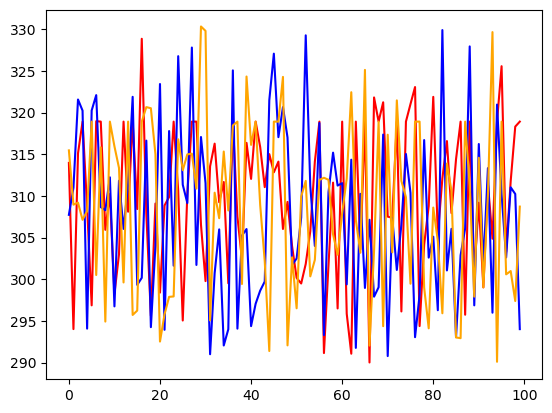

In [44]:
plt.plot(res4[0][1], c="red")
plt.plot(res4[1][1], c="blue")
plt.plot(res4[2][1], c="orange")
plt.show()

Ejercicio 2, se corren 5 iteraciones del mismo problema:

In [47]:
differential_evolution(fo2, 1, -32.768, 32.768, 100, 0.5, 0.5, 100)

def resultados(n):
    resultado = []
    i = 1
    while i <= n:
        resultado.append(differential_evolution(fo2, 1, -32.768, 32.768, 100, 0.5, 0.5, 100))
        i = i + 1
    return resultado

res5 = resultados(5)

En este caso vemos que el valor promedio es de aprox. 14.45 para el primer resultado:

In [49]:
np.mean(res5[0][1])

14.453300553606741

In [51]:
np.mean(res5[1][1])

13.692466130372138

Visualizando los primeros dos resultados, toman valores muy variados pero al final se aproximan:

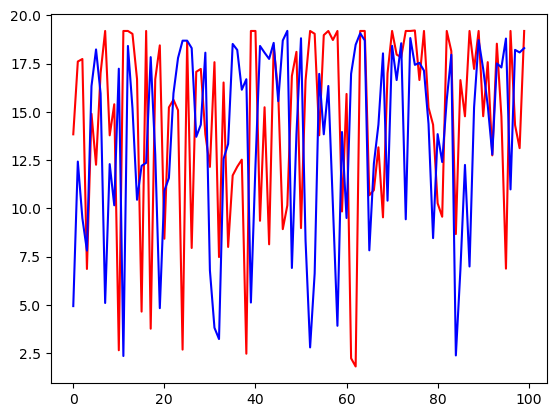

In [50]:
plt.plot(res5[0][1], c="red")
plt.plot(res5[1][1], c="blue")
plt.show()

Ejercicio 3, se corren 5 iteraciones del mismo problema:

In [53]:
#differential_evolution(fo3, 1, -10, 10, 100, 0.5, 0.5, 100)

def resultados(n):
    resultado = []
    i = 1
    while i <= n:
        resultado.append(differential_evolution(fo3, 2, -10, 10, 100, 0.5, 0.5, 100))
        i = i + 1
    return resultado

res6 = resultados(5)

En este caso obtenemos un valor promedio considerablemente grande en el primer y segundo resultado:

In [55]:
np.mean(res6[0][1])

3.9609733531870956e+18

In [56]:
np.mean(res6[1][1])

1.1927377490391515e+19

De manera gráfica se puede ver, que si bien llega a tomar valores considerablemente grandes, al final se aproxima a la primer solución del ejercicio anterior.

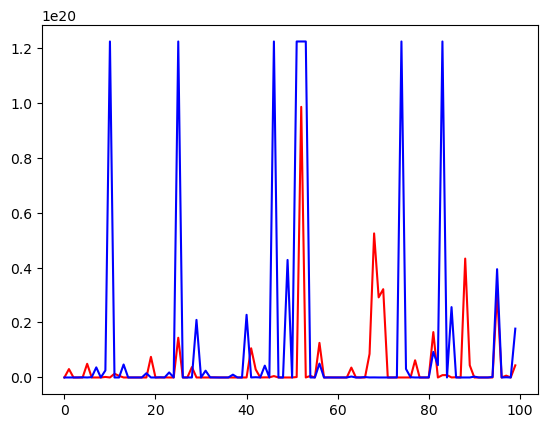

In [57]:
plt.plot(res6[0][1], c="red")
plt.plot(res6[1][1], c="blue")
plt.show()

### 3. Resuelva los problemas de optimización del ejercicio 1, usando optimización por enjambre de partículas con un tamaño de población de 100, durante 100 iteraciones y los parámetros $\omega = 0.5$ y $C1 = 1$ y $C2 = 1$.

In [58]:
import numpy as np
from sklearn.utils import check_random_state

def pso(fun, n_dim, lower_bound = 0, upper_bound = 1, swarm_size = 100, inertia_weight = .05, c1 = 2, c2 = 2, max_iters = 100, random_state = None):
    """Optimización por enjambre de partículas
    Args:
        fun (_type_): función objetivo a optimizar
        n_dim (int): número de variables del problema de optimización
        lower_bound (int, optional): límite inferior de las variables. Defaults to 0.
        upper_bound (int, optional): límite superior de las variables. Defaults to 1.
        swarm_size (int, optional): número de individuos en el enjambre. Defaults to 100.
        inertia_weight (float, optional): peso de inercia. Defaults to .05.
        c1 (float, optional): componente cognitivo y social. Defaults to 2.
        c2 (float, optional): componente cognitivo y social. Defaults to 2.
        max_iters (int, optional): número máximo de iteraciones/generaciones. Defaults to 100.
        random_State (int, optional): semilla de los números aleatorios. Defaults to None.
    """
    # Inicializar manejador de números aletorios
    random_state = check_random_state(random_state)
    # Crear enjambre inicial e inicializar velocidades en cero
    swarm_position = random_state.uniform(size = (swarm_size, n_dim))
    swarm_velocity = np.zeros((swarm_size, n_dim))
    # Evaluando la calidad de cada partícula en el enjambre
    fit = [fun(np.subtract(upper_bound, lower_bound) * particle + lower_bound) for particle in swarm_position]
    fit = np.array(fit)
    # Definir cada partícula como su mejor posición
    personal_best = {'position': swarm_position, 'quality': fit}
    neighborhood = np.argsort(random_state.uniform(size = (swarm_size, swarm_size)))[:,:5]
    # Guardar la mejor partícula hasta el momento
    particle_best = {'position': swarm_position[np.argmin(fit)], 'quality': np.min(fit)}
    for _ in range(max_iters):
        # Dterminar la mejor partícula del vecindario y actualizar la velocidad
        idx_best = np.argmin(fit[neighborhood], axis = 1)
        swarm_velocity *= inertia_weight
        swarm_velocity += c1 * random_state.uniform() * np.subtract(personal_best['position'], swarm_position)
        swarm_velocity += c2 * random_state.uniform() * np.subtract(swarm_position[idx_best], swarm_position)
        # Desplazar la partícula
        swarm_position = np.clip(swarm_position + swarm_velocity, 0, 1)
        # Evaluando el fitness de la población descendiente
        fit = [fun(np.subtract(upper_bound, lower_bound) * particle + lower_bound) for particle in swarm_position]
        fit = np.array(fit)
        # Comparar si mejora su mejor posición
        is_improved = np.where(fit < personal_best['quality'], True, False)
        if np.any(is_improved):
            personal_best['position'][is_improved] = swarm_position[is_improved]
            personal_best['quality'][is_improved] = fit[is_improved]
        # Compara si es la mejor global
        if np.min(fit) < particle_best['quality']:
            particle_best = {'position' : swarm_position[np.argmin(fit)], 'quality' : np.min(fit)}
    particle_best['position'] *= np.subtract(upper_bound, lower_bound)
    particle_best['position'] += lower_bound
    return np.add(np.subtract(upper_bound, lower_bound) * swarm_position, lower_bound), fit, particle_best

Ejercicio 1, obtenemos 5 iteraciones del mismo problema:

In [59]:
#pso(fo1, 1,-5.12, 5.12, 100, 0.5, 1, 1, 100)

def resultados(n):
    resultado = []
    i = 1
    while i <= n:
        resultado.append(pso(fo1, 1,-5.12, 5.12, 100, 0.5, 1, 1, 100))
        i = i + 1
    return resultado

res7 = resultados(5)

Obtenemos que el valor promedio es de 290.000 como en el primer resultado del primer ejercicio:

In [61]:
np.mean(res7[0][1])

290.0000000000048

En este caso, observamos la mejor posición y su calidad (290.0):

In [67]:
res7[0][2]

{'position': array([1.01393036e-08]), 'quality': 290.0}

Aquí observamos con el segundo resultado, como se aproxima al valor óptimo:

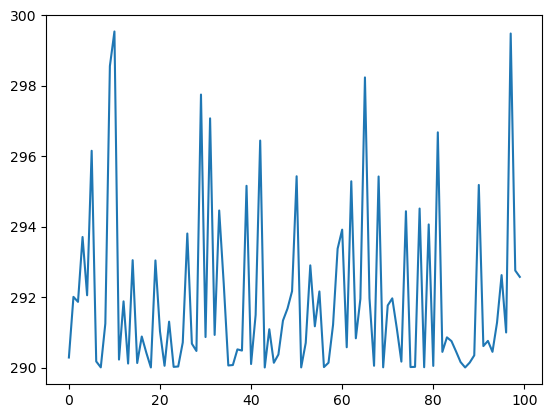

In [71]:
plt.plot(res7[1][1])
plt.show()

Ejercicio 2, lo corremos 5 veces:

In [72]:
#differential_evolution(fo2, 1, -32.768, 32.768, 100, 0.5, 0.5, 100)

def resultados(n):
    resultado = []
    i = 1
    while i <= n:
        resultado.append(pso(fo2, 1,-32.768, 32.768, 100, 0.5, 1, 1, 100))
        i = i + 1
    return resultado

res8 = resultados(5)

En este caso el valor promedio es similar a los resultados anteriores:

In [74]:
np.mean(res8[0][1])


1.6131987126191563

In [75]:
np.mean(res8[1][1])

1.6131987126191563

Observaos la mejor posición y su calidad, en dos resultados diferentes:

In [77]:
res8[0][2]

{'position': array([3.57616159e-10]), 'quality': 1.613110910835751}

In [78]:
res8[3][2]

{'position': array([4.07609946e-10]), 'quality': 1.6131109108989894}

De manera gráfica, observamos como se aproximan al valor óptimo:

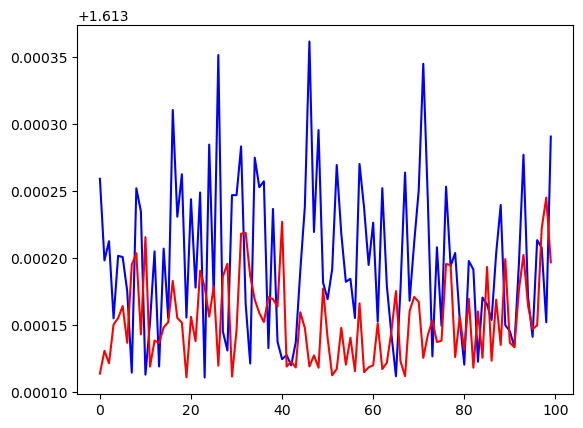

In [82]:
plt.plot(res8[1][1], c="blue")
plt.plot(res8[4][1], c="red")
plt.show()

Ejercicio 3, lo corremos 5 veces

In [83]:
#differential_evolution(fo3, 1, -10, 10, 100, 0.5, 0.5, 100)

def resultados(n):
    resultado = []
    i = 1
    while i <= n:
        resultado.append(pso(fo3, 2, -10, 10, 100, 0.5, 1, 1, 100))
        i = i + 1
    return resultado

res9 = resultados(5)

En este caso el valor óptimo es casi 0:

In [84]:
np.mean(res9[0][1])

3.230549325368434e-07

En cuanto a la posición y su calidad, se confirma que también es casi 0:

In [85]:
res9[0][2]

{'position': array([7.21264203, 1.        ]), 'quality': 4.093492029288253e-13}

De manera gráfica se puede apreciar como en una iteración los valores son muy variables, pero al final logra obtener la solución óptima:

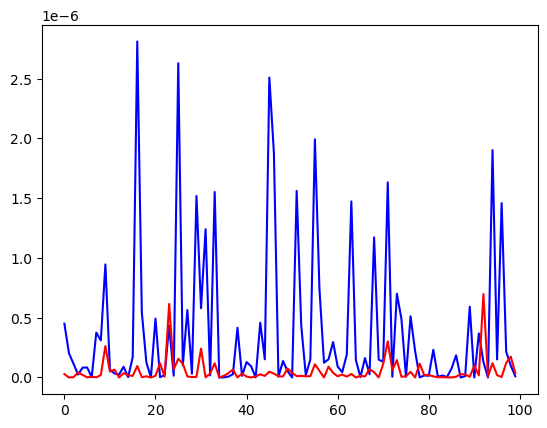

In [86]:
plt.plot(res9[1][1], c="blue")
plt.plot(res9[4][1], c="red")
plt.show()

### 4. Considere el método de regresión lineal con gradiente estocástico. Genere un conjunto de datos artificial con 10,000 ejemplos y 50 características. Evalúe el desempeño de la regresión lineal con gradiente estocástico considerando las tasas de aprendizaje de 0.001, 0.01 y 0.1. Compare en término de la aproximación da los valores de los coeficientes reales y la velocidad de convergencia.

In [89]:
import numpy as np
from sklearn.utils import check_X_y, check_random_state, shuffle

# Gradiente estocástico para regresión lineal
def stochastic_gradient(X, y, learning_rate = 0.001, max_iters = 1000, random_state = None):
    """Gradiente estocástico

    Args:
        X (array): tamaño m x n, m observaciones y n características
        y (array): tamaño m, la respuesta para cada observación
        learning_rate (float, optional): mayor que 0 y menor igual a 1. Defaults to 0.001.
        max_iters (int, optional): número máximo de iteraciones. Defaults to 1000.
        random_state (int, optional): semilla para el manejador de números aleatorios. Defaults to None.
    """
    
    # Inicializar manejador de números aleatorios
    random_state = check_random_state(random_state)
    
    # Verificar las entradas X e y
    X, y = check_X_y(X, y)
    
    # Definir el modelo inicial
    intercept = 0
    omega = np.zeros((X.shape[1]))
    
    # Proceso iterativo de gradiente estocástico
    for i in range(max_iters):
        # Ordenar aleatoriamente el conjunto de datos
        X, y = shuffle(X, y, random_state= random_state)
        for x_i, y_i in zip(X,y):
            grad_intercept = -2 * (y_i - intercept - np.dot(omega, x_i))
            grad_omega = -2 * (y_i - intercept - np.dot(omega, x_i)) * x_i
            intercept -= (learning_rate * grad_intercept)
            omega -= (learning_rate * grad_omega)
    return omega, intercept

Se genera una base de datos aleatoria de 10000 muestras y 50 características:

In [90]:
import numpy as np
from sklearn import datasets

X, y = datasets.make_classification(n_samples = 10000, n_features = 50)


Corremos la función de gradiente estocástico y recolecatamos los resultados por separado, con una tasa de aprendizaje de 0.001:

In [93]:
import time

# Start timer
start_time = time.time()

omega1, intercept1 = stochastic_gradient(X, y, learning_rate=0.001)

# End timer
end_time = time.time()

# Calculate elapsed time
elapsed_time = end_time - start_time
print("Elapsed time: ", elapsed_time) 

Elapsed time:  74.16768217086792


En este caso el algoritmó tardo 74.16 segundos en llevar a cabo la estimación, obteniendo los siguientes resultados:

In [92]:
print(omega1)
print(intercept1)

[-0.00365287 -0.08494606 -0.00184399 -0.01511146  0.01360706  0.00204674
 -0.00204518 -0.00741708  0.02003671  0.00412079 -0.00109717 -0.00523334
 -0.00518782 -0.10998755 -0.0117172   0.01355009 -0.01592077 -0.00292468
 -0.01329201 -0.00535921  0.00909109  0.01499787  0.00263485 -0.00046012
  0.00857393  0.14052667  0.013473    0.01809829 -0.00774951 -0.00509166
 -0.00696523  0.00554606 -0.00063539 -0.00669625 -0.00359956  0.01313653
 -0.01346442  0.01093578  0.01044452  0.00371501 -0.00693793  0.00555293
 -0.01525534 -0.01885527 -0.01501925 -0.01012968  0.001977   -0.01347637
  0.01431036  0.00134733]
0.47249497070097113


Se corre una segunda vez el algoritmo, con la misma base de datos, pero con una tasa de aprendizaje de 0.01 y se toma el tiempo:

In [95]:
import time

# Start timer
start_time = time.time()

omega2, intercept2 = stochastic_gradient(X, y, learning_rate=0.01)

# End timer
end_time = time.time()

# Calculate elapsed time
elapsed_time = end_time - start_time
print("Elapsed time: ", elapsed_time) 


Elapsed time:  73.08863687515259


En este caso el tiempo transcurrido fue similar a una tasa de 0.001, obteniendo los siguientes resultados, siendo un poco diferente el intercepto:

In [99]:
print(omega2)
print(intercept2)

[ 0.04583426 -0.09838265 -0.05124442  0.03243062  0.00726993 -0.05671738
  0.00126     0.04833638  0.07544446 -0.06598323 -0.01050268 -0.01760466
 -0.04734852 -0.12334049 -0.01129806  0.00240011 -0.08200165 -0.0211939
 -0.0313935   0.04683407  0.04735408  0.05214968 -0.03283477  0.00388029
  0.05950577  0.15850433  0.02319545  0.04237044 -0.01636827 -0.0547155
 -0.00338561  0.0059124   0.02023546 -0.03506715 -0.0478049   0.04105054
  0.01999098 -0.05840938  0.03603444 -0.00475924  0.01003561  0.03038419
  0.04481663  0.06177327 -0.0631107  -0.00896757  0.03219548 -0.09829254
  0.01179448  0.04377922]
0.5686679694133312


Se corre una tercera vez el algoritmo, con una tasa de aprendizaje del 0.1:

In [97]:
import time

# Start timer
start_time = time.time()

omega3, intercept3 = stochastic_gradient(X, y, learning_rate=0.1)

# End timer
end_time = time.time()

# Calculate elapsed time
elapsed_time = end_time - start_time
print("Elapsed time: ", elapsed_time) 

/var/folders/dp/hjbpmxsx7797vz0btvv75yh00000gn/T/ipykernel_3631/4067277165.py:34: RuntimeWarning: overflow encountered in multiply
  grad_omega = -2 * (y_i - intercept - np.dot(omega, x_i)) * x_i


Elapsed time:  73.68351197242737


En este caso el tiempo de ejecución fue similar, obteniendo lo siguiente, probablemente a consecuencia del algoritmo que sobrepasa la memoria alojada al multiplicar la tasa de 0.1 por el valor del gradiente del intercepto:

In [98]:
print(omega3)
print(intercept3)

[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
nan
